In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


После парсинга данных и получение их через API у нас получились датасеты, которые перед разведовательным анализом нужно привести в порядок, начнем с датасета, в котором мы парсили данные. Очистка будет делаться в несколько этапов:

- Удаление ненужных признаков для анализа
- Удаление мусора в столбцах
- Работа с пропусками и дубликатами
- Приведение типов данных


In [ ]:
df1 = pd.read_csv('allmusic_final.csv')
df1.head()


,week_date,artist,album_title,label,genre,rating,album_url,text_description,release_date,duration,styles,image_url
0,20260410,36 Crazyfists,Rest Inside the Flames,Music on Vinyl,Pop/Rock,8,https://www.allmusic.com/album/rest-inside-the...,Rest Inside the Flames by 36 Crazyfists releas...,"June 26, 2006",40:25,"Alternative Metal , Heavy Metal , Alternative/...",https://fastly-s3.allmusic.com/release/mr00012...
1,20260410,3TM,Lake,Ultra Vybe,Jazz,NaN,https://www.allmusic.com/album/lake-mw0003323509,"Lake by 3TM. Find album reviews, track lists, ...",NaN,NaN,NaN,https://fastly-gce.allmusic.com/images/allmusi...
2,20260410,A$AP Rocky,Don't Be Dumb,Columbia / RCA,Rap,7,https://www.allmusic.com/album/dont-be-dumb-mw...,Don't Be Dumb by A$AP Rocky released in 2026. ...,"January 16, 2026",51:55,"Contemporary Rap , East Coast Rap , Cloud Rap ...",https://fastly-s3.allmusic.com/release/mr00069...
3,20260410,AblaBoye,Nuages,Tamya Production,International,NaN,https://www.allmusic.com/album/nuages-mw000478...,Nuages by AblaBoye released in 2026. Find albu...,"April 7, 2026",03:43,NaN,https://fastly-s3.allmusic.com/release/mr00070...
4,20260410,Adam Klemens / FILMharmonic Orchestra Prague,Dave Soldier: Vipers at the Onyx,Bright Shiny Things,Jazz,NaN,https://www.allmusic.com/album/dave-soldier-vi...,Dave Soldier: Vipers at the Onyx by Adam Kleme...,"April 10, 2026",NaN,"Crossover Jazz , Orchestral , Classical Crosso...",https://fastly-s3.allmusic.com/release/mr00070...


In [ ]:
df1.shape

(20167, 12)

У нас 12 признаков и нанем с удаления служебных, а именно признаков, которые содержат URL на альбом и на обложку альбома, они в EDA нам не нужны. (album_url,image_url). Также удалим признак text_discription, так как он дублирует информацию нескольких других (artist, release_date, album_title)

In [ ]:
df1 = df1.drop(columns=['album_url', 'image_url','text_description'])


In [ ]:
df1.head(100)

,week_date,artist,album_title,label,genre,rating,release_date,duration,styles
0,20260410,36 Crazyfists,Rest Inside the Flames,Music on Vinyl,Pop/Rock,8,"June 26, 2006",40:25,"Alternative Metal , Heavy Metal , Alternative/..."
1,20260410,3TM,Lake,Ultra Vybe,Jazz,NaN,NaN,NaN,NaN
2,20260410,A$AP Rocky,Don't Be Dumb,Columbia / RCA,Rap,7,"January 16, 2026",51:55,"Contemporary Rap , East Coast Rap , Cloud Rap ..."
3,20260410,AblaBoye,Nuages,Tamya Production,International,NaN,"April 7, 2026",03:43,NaN
4,20260410,Adam Klemens / FILMharmonic Orchestra Prague,Dave Soldier: Vipers at the Onyx,Bright Shiny Things,Jazz,NaN,"April 10, 2026",NaN,"Crossover Jazz , Orchestral , Classical Crosso..."
...,...,...,...,...,...,...,...,...,...
95,20260410,Esa Williams,Dala What We Must,BBE,International,NaN,"April 10, 2026",NaN,NaN
96,20260410,Fantastic Cat,Cat out of Hell,Missing Piece Records,Pop/Rock,NaN,"April 10, 2026",NaN,Alternative/Indie Rock Set Your Streaming Serv...
97,20260410,Fauna,Taiga Trans,Glitterbeat,Electronic,NaN,NaN,NaN,Club/Dance Set Your Streaming Service Suggest ...
98,20260410,Faze Action,Distant Dreams,Faze Action,Electronic,NaN,"April 10, 2026",NaN,NaN


In [ ]:
df1['rating'].unique()

array(['8', nan, '7', '5', 'Pop/Rock', '3', '2', '6', 'Jazz', '9', '4',
       'Folk', '1', 'International', 'Avant-Garde', 'Country',
       'Electronic', 'R&B', 'Universal', 'Rap', 'Latin', 'Reggae',
       'New Age', 'Stage & Screen', 'Classical', 'Kris Kristofferson',
       'Millennium Audio & Video', 'Deko Entertainment / DEKO Music',
       'Tips Industries', 'GJG', 'Religious', "Children's", 'Year0001',
       'Ermitage', 'THEBLACKLABEL'], dtype=object)

Теперь переходим к работе с мусором в ячейках и приведению их к номарльному виду.

- в признаке Rating есть значение, где вместо одной цифры находится текст - это возможно из-за сдвига в парсинге.

In [ ]:
df1 = df1[df1['rating'].isna() | df1['rating'].str.isnumeric()]
df1['rating'] = df1['rating'].astype(float)


In [ ]:
df1['rating'].unique()

array([ 8., nan,  7.,  5.,  3.,  2.,  6.,  9.,  4.,  1.])

Так, теперь у нас есть проблема в признаке styles, там тоже к жанрам добавился мусор в конце по типу: Listen on Amazon Listen on Spotify Listen on Apple Music Set Your Streaming Service Suggest Streaming Links To Set Your Preferred Streaming Service, Log In to Your AllMusic Account To Submit Streaming Links, Log In to Your AllMusic Account Log In Don't have an Account?

In [ ]:
df1['styles'].unique()

array(['Alternative Metal , Heavy Metal , Alternative/Indie Rock , Post-Hardcore',
       nan,
       "Contemporary Rap , East Coast Rap , Cloud Rap , Alternative Rap Listen on Amazon Listen on Spotify Listen on Apple Music Set Your Streaming Service Suggest Streaming Links To Set Your Preferred Streaming Service, Log In to Your AllMusic Account To Submit Streaming Links, Log In to Your AllMusic Account Log In Don't have an Account?",
       ...,
       "Acid Rock , Psychedelic/Garage , Rock & Roll , Psychedelic Pop , Album Rock , Psychedelic Set Your Streaming Service Suggest Streaming Links To Set Your Preferred Streaming Service, Log In to Your AllMusic Account To Submit Streaming Links, Log In to Your AllMusic Account Log In Don't have an Account? AllMusic Review User Reviews Track Listing Credits Releases Similar Albums Moods and Themes",
       'Keyboard Recording Date April 20, 2021 - April 22, 2021',
       "Chamber Music , Neo-Classical Set Your Streaming Service Suggest Strea

In [ ]:
df1['styles'] = df1['styles'].str.replace(r'\s*(Listen on|Set Your|Log In).*$', '', regex=True)
df1['styles'] = df1['styles'].str.strip()
df1['styles'] = df1['styles'].str.rstrip(',').str.strip()
df1

,week_date,artist,album_title,label,genre,rating,release_date,duration,styles
0,20260410,36 Crazyfists,Rest Inside the Flames,Music on Vinyl,Pop/Rock,8.0,"June 26, 2006",40:25,"Alternative Metal , Heavy Metal , Alternative/..."
1,20260410,3TM,Lake,Ultra Vybe,Jazz,NaN,NaN,NaN,NaN
2,20260410,A$AP Rocky,Don't Be Dumb,Columbia / RCA,Rap,7.0,"January 16, 2026",51:55,"Contemporary Rap , East Coast Rap , Cloud Rap ..."
3,20260410,AblaBoye,Nuages,Tamya Production,International,NaN,"April 7, 2026",03:43,NaN
4,20260410,Adam Klemens / FILMharmonic Orchestra Prague,Dave Soldier: Vipers at the Onyx,Bright Shiny Things,Jazz,NaN,"April 10, 2026",NaN,"Crossover Jazz , Orchestral , Classical Crossover"
...,...,...,...,...,...,...,...,...,...
20162,20251128,Zaxe,STAY AWAY,Label Blue Sky,Rap,NaN,"November 27, 2025",02:32,NaN
20163,20251128,Zbigniew Namysłowski / Zbigniew Namysłowski Mo...,Lola,Decca,Jazz,5.0,"September 18, 1964",NaN,Fusion
20164,20251128,Zeca Veloso,Boas Novas,Sony Music,Pop/Rock,NaN,"November 26, 2025",34:03,NaN
20165,20251128,Zeyneb Nezerova,Peşman Olarsan,WediaCorp Music,Pop/Rock,NaN,"November 29, 2025",04:27,NaN


Теперь перейдем к работе с пропусками и дубликатами. Для начала разберемся с дубликатами. Посмотрим полные дубли и дубли, если релизы попали в разные недели

In [ ]:
df1.shape[0]

19909

Количество полных дублей

In [ ]:
df1.duplicated().sum()


np.int64(1)

Количество дублей по столбцам (artist и album_title) мы смотрим дубликаты, если например у нас один альбом в разные недели релиза попал

In [ ]:
df1.duplicated(subset=['artist', 'album_title']).sum()


np.int64(14)

Удаляем дубликаты, автоматически удалятся и полные и по этим двум столбцам

In [ ]:
df1 = df1.drop_duplicates(subset=['artist', 'album_title'], keep='first')

Количество строк после удаления дубликатов

In [ ]:
df1.shape[0]

19895

Теперь посмотрим пропуски в датафрейме и поймем природу пропусков в кажом признаке. Глянем процент пропусков в признаке относительно всех наблюдений

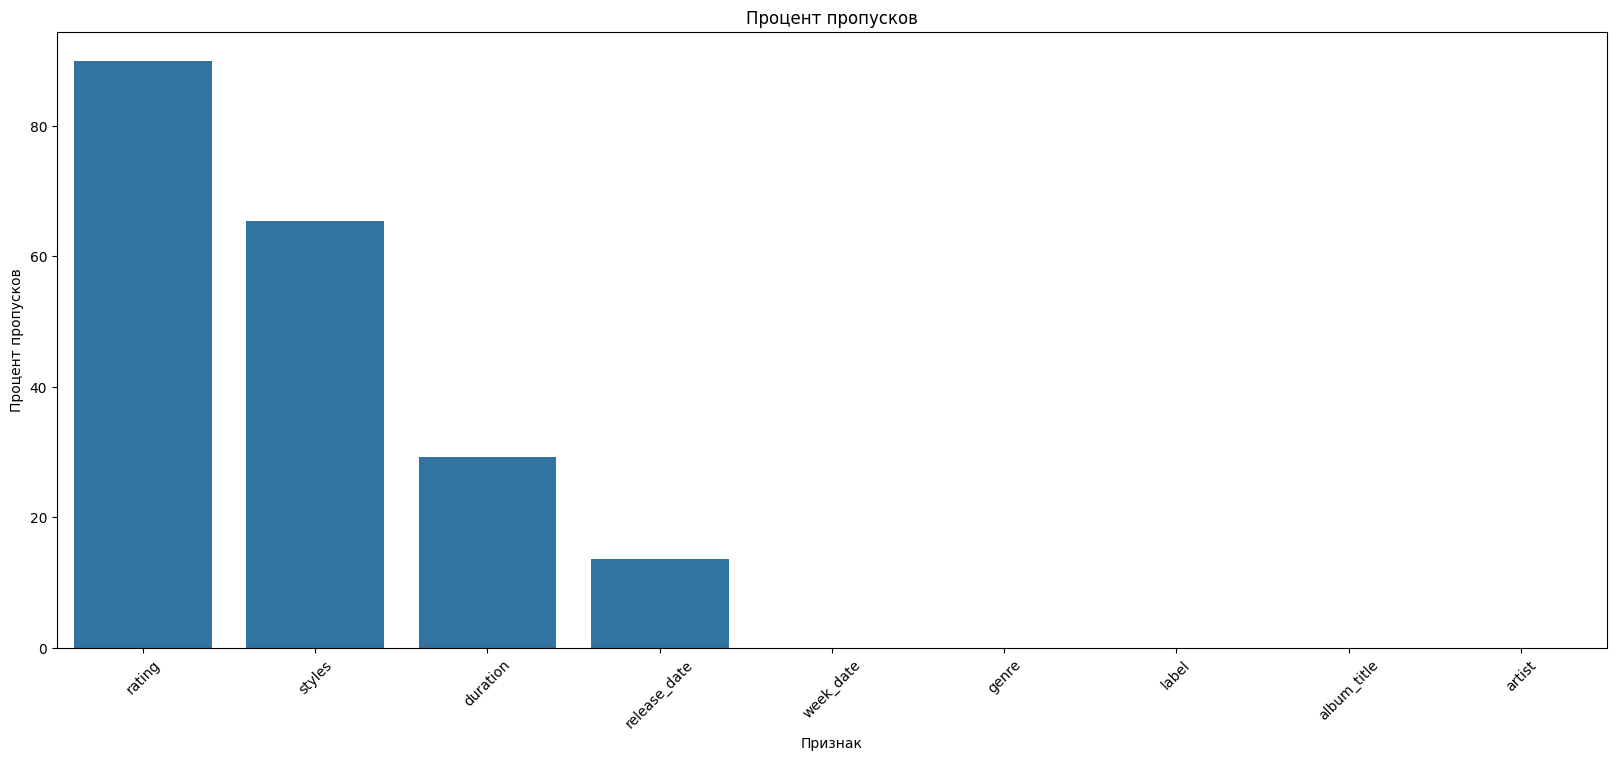

In [ ]:
missing = df1.isnull().mean().sort_values(ascending=False) * 100

plt.figure(figsize=(20, 8))
sns.barplot(
    x=missing.index,
    y=missing.values
)

plt.xlabel("Признак")
plt.ylabel("Процент пропусков")
plt.xticks(rotation=45)
plt.title("Процент пропусков")
plt.show()

О чем на говорят пропуски?

- rating - у большинства альбомов просто нет рейтинга от редакции
- release_date - дата не указана
- duration - длительность не указана
- styles - cтили не указаны на сайте

Что мы будем с ними делать? Наличие пропусков говорит на о остутсвии информации на сайте, поэтому заполнять rating средним будет неправильно, так как это ложная информация и у нас в этом столбце больше 80% пропусков, но признак может нести что-то на подвыборке. Поскольку мы не строим ML модель, которая плохо работает с пропусками, а просто анализируем данные и делаем выводы, то при анализе признаков будем использовать подвыборки с непустыми значениями. А вот признак duration имеет всего около 29% пропусков, поэтому давайте посмотрим на распределение этого признака и на boxplot, но сделаем мы это после того, как приведем в порядок тип данных этого признака.

Теперь приведем типы данных:

- столбцы week_date и realease_date к Datetime
- столбец duration к типу данных float в минутах

In [ ]:
df1['week_date'] = pd.to_datetime(df1['week_date'].astype(str), format='%Y%m%d')

/tmp/ipykernel_5394/2660738240.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['week_date'] = pd.to_datetime(df1['week_date'].astype(str), format='%Y%m%d')


In [ ]:
df1['release_date'] = pd.to_datetime(df1['release_date'], format='%B %d, %Y', errors='coerce')


/tmp/ipykernel_5394/1006052552.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['release_date'] = pd.to_datetime(df1['release_date'], format='%B %d, %Y', errors='coerce')


Ссылка на метод apply, который используется в нижней ячейке: https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.apply.html

In [ ]:
df1['duration'] = df1['duration'].str.split(':').apply(lambda x: round(int(x[0]) + int(x[1]) / 60) if type(x) == list else None)
df1

/tmp/ipykernel_5394/2681383654.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['duration'] = df1['duration'].str.split(':').apply(lambda x: round(int(x[0]) + int(x[1]) / 60) if type(x) == list else None)


,week_date,artist,album_title,label,genre,rating,release_date,duration,styles
0,2026-04-10,36 Crazyfists,Rest Inside the Flames,Music on Vinyl,Pop/Rock,8.0,2006-06-26,40.0,"Alternative Metal , Heavy Metal , Alternative/..."
1,2026-04-10,3TM,Lake,Ultra Vybe,Jazz,NaN,NaT,NaN,NaN
2,2026-04-10,A$AP Rocky,Don't Be Dumb,Columbia / RCA,Rap,7.0,2026-01-16,52.0,"Contemporary Rap , East Coast Rap , Cloud Rap ..."
3,2026-04-10,AblaBoye,Nuages,Tamya Production,International,NaN,2026-04-07,4.0,NaN
4,2026-04-10,Adam Klemens / FILMharmonic Orchestra Prague,Dave Soldier: Vipers at the Onyx,Bright Shiny Things,Jazz,NaN,2026-04-10,NaN,"Crossover Jazz , Orchestral , Classical Crossover"
...,...,...,...,...,...,...,...,...,...
20162,2025-11-28,Zaxe,STAY AWAY,Label Blue Sky,Rap,NaN,2025-11-27,3.0,NaN
20163,2025-11-28,Zbigniew Namysłowski / Zbigniew Namysłowski Mo...,Lola,Decca,Jazz,5.0,1964-09-18,NaN,Fusion
20164,2025-11-28,Zeca Veloso,Boas Novas,Sony Music,Pop/Rock,NaN,2025-11-26,34.0,NaN
20165,2025-11-28,Zeyneb Nezerova,Peşman Olarsan,WediaCorp Music,Pop/Rock,NaN,2025-11-29,4.0,NaN


Теперь посмотрим на распределение и boxplot признака duration

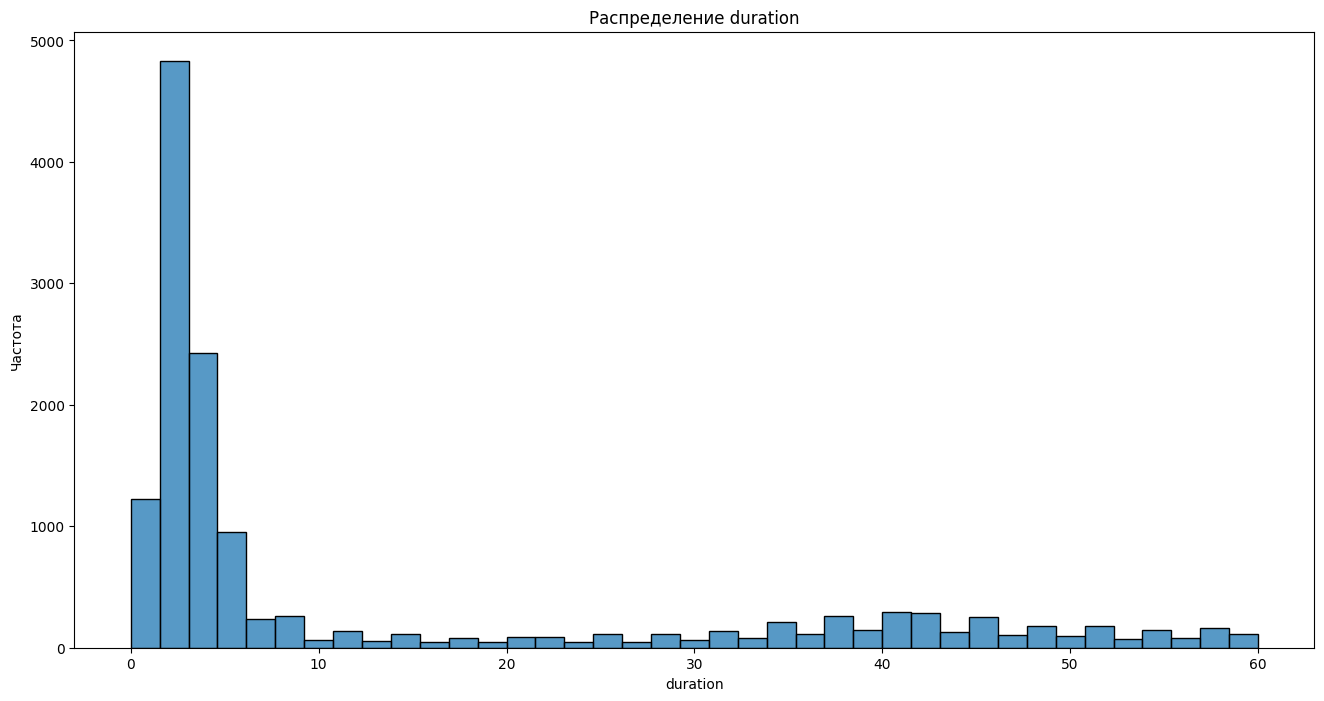

In [ ]:
plt.figure(figsize=(16,8))
sns.histplot(df1['duration'])

plt.title('Распределение duration')
plt.xlabel('duration')
plt.ylabel('Частота')

plt.show()

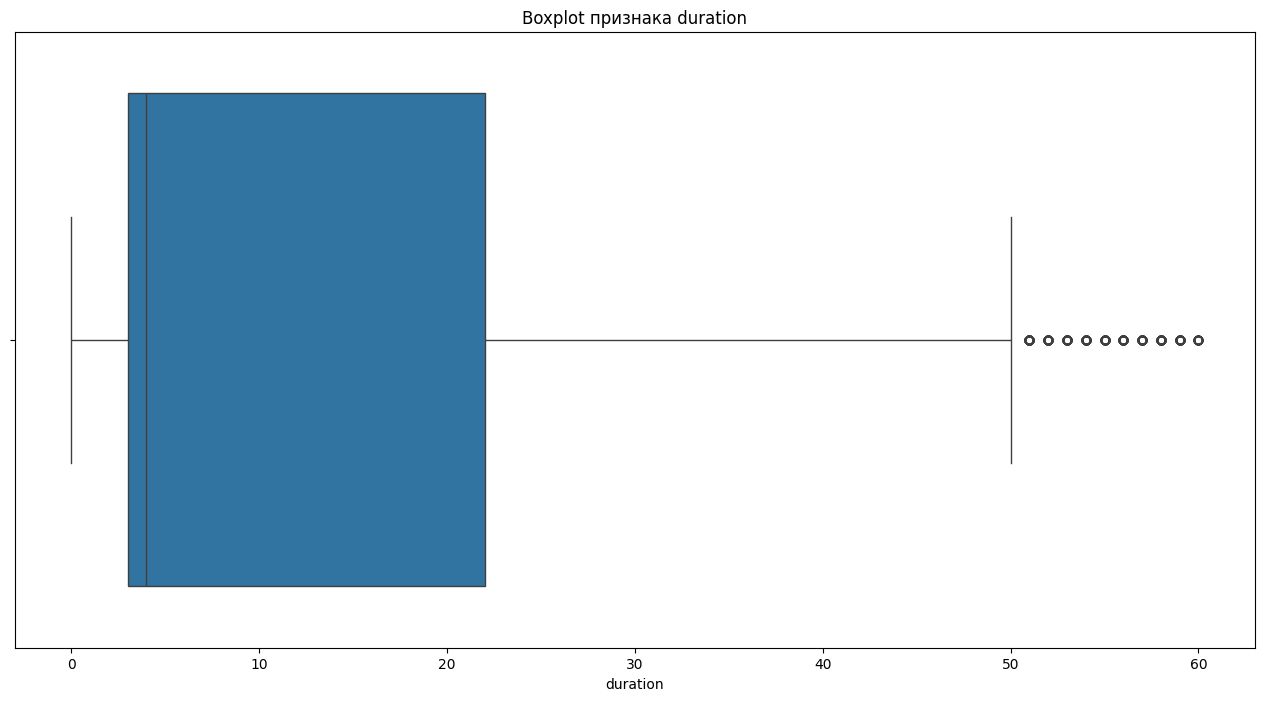

In [ ]:
plt.figure(figsize=(16,8))
sns.boxplot(x=df1['duration'])
plt.title('Boxplot признака duration')
plt.show()

Мы можем увидеть, что распределение несимметричное, на boxplot у нас много выбросов и среднее будет искажено, поэтому мы не можем ни на что заменять duration, так как у нас есть много альбомов, где длительность равна 3-5 минут, и мы не будуем искажать данные

Добавим один новый признак, который возможно поможет нам в дальнейшем EDA - год релиза альбома, просто извлечение года из признака release_date

In [ ]:
df1['release_year'] = df1['release_date'].dt.year
df1.head()

/tmp/ipykernel_5394/4213425181.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['release_year'] = df1['release_date'].dt.year


,week_date,artist,album_title,label,genre,rating,release_date,duration,styles,release_year
0,2026-04-10,36 Crazyfists,Rest Inside the Flames,Music on Vinyl,Pop/Rock,8.0,2006-06-26,40.0,"Alternative Metal , Heavy Metal , Alternative/...",2006.0
1,2026-04-10,3TM,Lake,Ultra Vybe,Jazz,NaN,NaT,NaN,NaN,NaN
2,2026-04-10,A$AP Rocky,Don't Be Dumb,Columbia / RCA,Rap,7.0,2026-01-16,52.0,"Contemporary Rap , East Coast Rap , Cloud Rap ...",2026.0
3,2026-04-10,AblaBoye,Nuages,Tamya Production,International,NaN,2026-04-07,4.0,NaN,2026.0
4,2026-04-10,Adam Klemens / FILMharmonic Orchestra Prague,Dave Soldier: Vipers at the Onyx,Bright Shiny Things,Jazz,NaN,2026-04-10,NaN,"Crossover Jazz , Orchestral , Classical Crossover",2026.0


In [ ]:
df1.head()

,week_date,artist,album_title,label,genre,rating,release_date,duration,styles,release_year
0,2026-04-10,36 Crazyfists,Rest Inside the Flames,Music on Vinyl,Pop/Rock,8.0,2006-06-26,40.0,"Alternative Metal , Heavy Metal , Alternative/...",2006.0
1,2026-04-10,3TM,Lake,Ultra Vybe,Jazz,NaN,NaT,NaN,NaN,NaN
2,2026-04-10,A$AP Rocky,Don't Be Dumb,Columbia / RCA,Rap,7.0,2026-01-16,52.0,"Contemporary Rap , East Coast Rap , Cloud Rap ...",2026.0
3,2026-04-10,AblaBoye,Nuages,Tamya Production,International,NaN,2026-04-07,4.0,NaN,2026.0
4,2026-04-10,Adam Klemens / FILMharmonic Orchestra Prague,Dave Soldier: Vipers at the Onyx,Bright Shiny Things,Jazz,NaN,2026-04-10,NaN,"Crossover Jazz , Orchestral , Classical Crossover",2026.0


In [ ]:
df1.to_csv('final_df1_cleaned.csv', index=False)

==========================================================================================

**Теперь очистка файла, который мы спарсили с помощью API**

In [ ]:
df = pd.read_csv('lastfm_api.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20151 entries, 0 to 20150
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   artist           19909 non-null  object 
 1   album_title      20151 non-null  object 
 2   listeners        13064 non-null  float64
 3   playcount        13064 non-null  float64
 4   artist_bio       15325 non-null  object 
 5   track_listeners  6388 non-null   float64
 6   top_tracks       15325 non-null  object 
 7   top_albums       15156 non-null  object 
dtypes: float64(3), object(5)
memory usage: 1.2+ MB


In [ ]:
df.describe()

,listeners,playcount,track_listeners
count,1.306400e+04,1.306400e+04,6.388000e+03
mean,1.993991e+04,4.284317e+05,1.169016e+04
std,1.103358e+05,4.716241e+06,8.006615e+04
min,0.000000e+00,0.000000e+00,1.000000e+00
25%,0.000000e+00,0.000000e+00,4.000000e+00
50%,3.250000e+01,1.490000e+02,6.500000e+01
75%,1.369500e+03,9.784750e+03,1.083500e+03
max,2.628806e+06,3.130442e+08,2.355541e+06


In [ ]:
missing_count = df.isna().sum()
missing_share = (df.isna().sum() / len(df) * 100).sort_values(ascending=False)

missing_count, missing_share

(artist               242
 album_title            0
 listeners           7087
 playcount           7087
 artist_bio          4826
 track_listeners    13763
 top_tracks          4826
 top_albums          4995
 dtype: int64,
 track_listeners    68.299340
 playcount          35.169470
 listeners          35.169470
 top_albums         24.787852
 artist_bio         23.949184
 top_tracks         23.949184
 artist              1.200933
 album_title         0.000000
 dtype: float64)

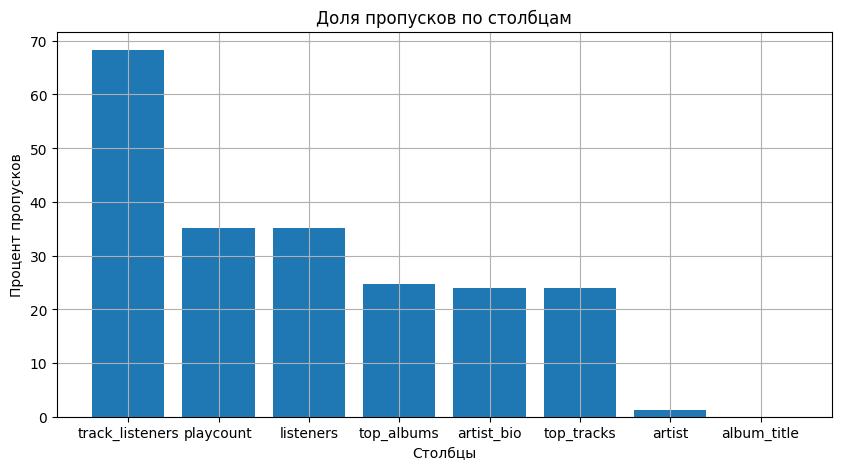

In [ ]:
plt.figure(figsize=(10, 5))
plt.bar(missing_share.index, missing_share.values)
plt.title('Доля пропусков по столбцам')
plt.xlabel('Столбцы')
plt.ylabel('Процент пропусков')
plt.grid()
plt.show()

In [ ]:
df_clean = df.copy()
df_clean.head()

,artist,album_title,listeners,playcount,artist_bio,track_listeners,top_tracks,top_albums
0,36 Crazyfists,Rest Inside the Flames,142201.0,3463219.0,36 Crazyfists was an alternative metal band fo...,16.0,"Bloodwork, At The End Of August, The Heart And...","A Snow Capped Romance, Bitterness the Star, Re..."
1,3TM,Lake,613.0,6562.0,3TM is a trio formation including Teppo Mäkyne...,318.0,"Five New Dukes, Laws Of Life, Flaigology, Seve...","Form, Lake, Abyss (A Prelude to Lake), Five Ne..."
2,A$AP Rocky,Don't Be Dumb,775666.0,20545054.0,"Rakim Athelston Mayers (born October 3, 1988),...",53.0,"Sundress, Praise the Lord (Da Shine) (feat. Sk...","LONG.LIVE.A$AP (Deluxe Version), AT.LONG.LAST...."
3,AblaBoye,Nuages,NaN,NaN,NaN,NaN,NaN,NaN
4,Adam Klemens / FILMharmonic Orchestra Prague,Dave Soldier: Vipers at the Onyx,NaN,NaN,NaN,NaN,NaN,NaN


Столбец artist является ключевым. Если имя исполнителя отсутствует, такие строки удаляем.

In [ ]:
df_clean = df_clean.dropna(subset=['artist'])


Для текстовых столбцов заменяем пропуски на понятные значения.

In [ ]:
df_clean['artist_bio'] = df_clean['artist_bio'].fillna('No bio')
df_clean['top_tracks'] = df_clean['top_tracks'].fillna('No top tracks')
df_clean['top_albums'] = df_clean['top_albums'].fillna('No top albums')

df_clean[['artist_bio', 'top_tracks', 'top_albums']].head()

,artist_bio,top_tracks,top_albums
0,36 Crazyfists was an alternative metal band fo...,"Bloodwork, At The End Of August, The Heart And...","A Snow Capped Romance, Bitterness the Star, Re..."
1,3TM is a trio formation including Teppo Mäkyne...,"Five New Dukes, Laws Of Life, Flaigology, Seve...","Form, Lake, Abyss (A Prelude to Lake), Five Ne..."
2,"Rakim Athelston Mayers (born October 3, 1988),...","Sundress, Praise the Lord (Da Shine) (feat. Sk...","LONG.LIVE.A$AP (Deluxe Version), AT.LONG.LAST...."
3,No bio,No top tracks,No top albums
4,No bio,No top tracks,No top albums


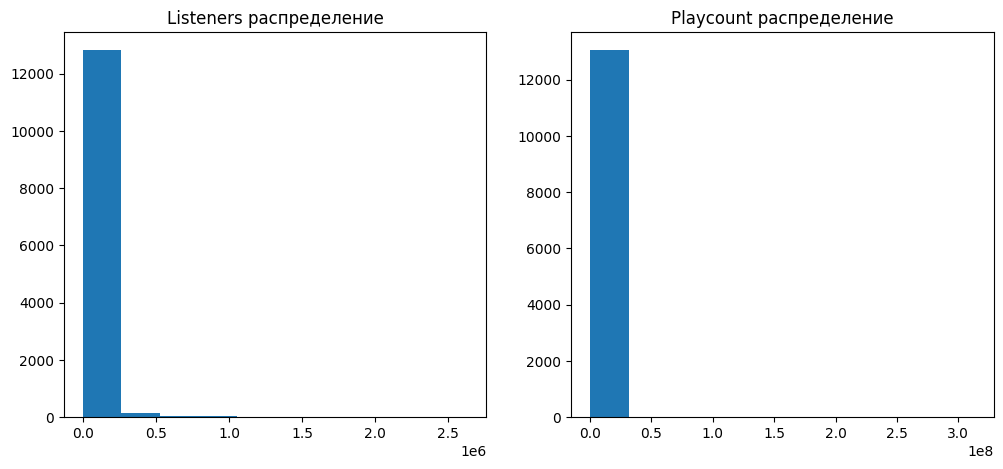

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df['listeners'].dropna())
plt.title('Listeners распределение')

plt.subplot(1, 2, 2)
plt.hist(df['playcount'].dropna())
plt.title('Playcount распределение')

plt.show()

сильная правосторонняя скошенность
длинный хвост вправо

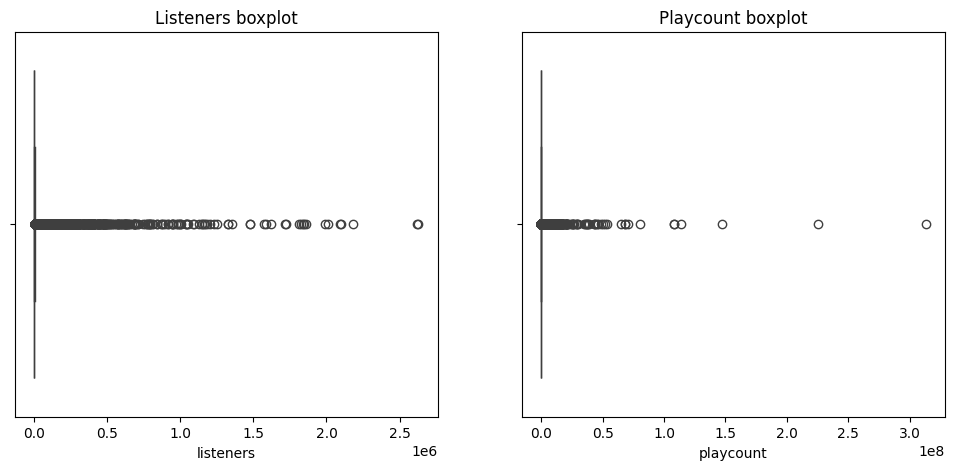

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x=df['listeners'])
plt.title('Listeners boxplot')

plt.subplot(1, 2, 2)
sns.boxplot(x=df['playcount'])
plt.title('Playcount boxplot')

plt.show()

куча выбросов (очень популярные треки)

Заменяем пропуски медианой по следующим причинам:
устойчива к выбросам
отражает середину данных
не искажается суперпопулярными треками

In [ ]:
df_clean['listeners'] = df_clean['listeners'].fillna(df_clean['listeners'].median())
df_clean['playcount'] = df_clean['playcount'].fillna(df_clean['playcount'].median())

In [ ]:
df_clean.isna().sum()

,0
artist,0
album_title,0
listeners,0
playcount,0
artist_bio,0
track_listeners,13521
top_tracks,0
top_albums,0


Удаляем колонку track_listeners, тк так больше половины пропусков

In [ ]:
df_clean = df_clean.drop(columns=['track_listeners'])

In [ ]:
df = df_clean

In [ ]:
df.head()

,artist,album_title,listeners,playcount,artist_bio,top_tracks,top_albums
0,36 Crazyfists,Rest Inside the Flames,142201.0,3463219.0,36 Crazyfists was an alternative metal band fo...,"Bloodwork, At The End Of August, The Heart And...","A Snow Capped Romance, Bitterness the Star, Re..."
1,3TM,Lake,613.0,6562.0,3TM is a trio formation including Teppo Mäkyne...,"Five New Dukes, Laws Of Life, Flaigology, Seve...","Form, Lake, Abyss (A Prelude to Lake), Five Ne..."
2,A$AP Rocky,Don't Be Dumb,775666.0,20545054.0,"Rakim Athelston Mayers (born October 3, 1988),...","Sundress, Praise the Lord (Da Shine) (feat. Sk...","LONG.LIVE.A$AP (Deluxe Version), AT.LONG.LAST...."
3,AblaBoye,Nuages,32.5,149.0,No bio,No top tracks,No top albums
4,Adam Klemens / FILMharmonic Orchestra Prague,Dave Soldier: Vipers at the Onyx,32.5,149.0,No bio,No top tracks,No top albums


In [ ]:
df.to_csv("lastfm_api_final.csv")